# HAI 23.05 — HIL-based Augmented ICS: dataset analysis

## What the dataset contains

HAI is a security dataset from Korea's National Security Research Institute, built
on a testbed that combines **three real laboratory processes with a
hardware-in-the-loop simulator**:

| process | what it is | controller |
|---|---|---|
| P1 | boiler — water-to-water heat transfer, pressure/level/flow/temperature control | Emerson Ovation DCS |
| P2 | turbine — a GE rotor kit with speed control and vibration monitoring | GE Mark VIe DCS |
| P3 | water treatment — pumping between upper and lower reservoirs | Siemens S7-300 PLC |
| P4 | HIL simulation — steam-turbine and pumped-storage hydropower generation | dSPACE SCALEXIO |

The HIL simulator is what makes the dataset unusual: it couples the three physical
processes through a simulated power grid, so a change in the boiler propagates to
the turbine and the water treatment. The official documentation states this was done
deliberately "to ensure that the variables were highly coupled and correlated for a
richer dataset".

Everything is sampled at **1 Hz**.

## Where to download it

> **Kaggle:** <https://www.kaggle.com/datasets/icsdataset/hai-security-dataset>

Four versions have been released, each a separate collection campaign:

| version | tags | normal | attacks |
|---|---|---|---|
| 20.07 | 59 | 2 files, 177 h | 2 files, 38 attacks |
| 21.03 | 78 | 3 files, 352 h | 5 files, 50 attacks |
| 22.04 | 86 | 6 files, 279 h | 4 files, 58 attacks |
| **23.05** | **86** | **4 files, 249 h** | **2 files, 52 attacks** |

In [1]:
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path("../data/raw/hai-23.05")

# Palette and chart chrome, applied once. Thin marks, solid hairline grid one
# shade off the surface, recessive axes.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
# Categorical slots in fixed order -- assigned by identity, never cycled.
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NORMAL, ATTACK = C[0], "#d03b3b"   # attack uses the critical status step: it means "bad"
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})
print("pandas", pd.__version__, "| matplotlib", mpl.__version__)

pandas 3.0.6 | matplotlib 3.11.2


---
## 1. The files

23.05 ships **four training files, two test files and two label files**. The labels
are *separate from the data*.

In [12]:
TRAIN = [f"hai-train{i}" for i in (1, 2, 3, 4)]
TEST = [f"hai-test{i}" for i in (1, 2)]
LABEL = [f"label-test{i}" for i in (1, 2)]

def read_time(name: str) -> pd.Series:
    return pd.to_datetime(pd.read_csv(BASE / f"{name}.csv", usecols=["timestamp"])["timestamp"])

print(f"{'file':<16}{'rows':>10}{'cols':>7}  {'from':<21}{'to':<21} {'memory':>7}")
spans = {}
for name in TRAIN + TEST + LABEL:
    head = pd.read_csv(BASE / f"{name}.csv")
    t = read_time(name)
    spans[name] = (t.min(), t.max(), len(t))
    print(f"{name:<16}{len(t):>10,}{head.shape[1]:>7}  {str(t.min()):<21}{str(t.max()):<21} {head.memory_usage(deep=True).sum() / 1e6:,.0f} MB")


file                  rows   cols  from                 to                     memory
hai-train1         280,800     87  2022-08-04 18:00:01  2022-08-08 00:00:00   201 MB
hai-train2         291,600     87  2022-08-13 07:00:01  2022-08-16 16:00:00   208 MB
hai-train3         126,000     87  2022-08-19 16:00:01  2022-08-21 03:00:00   90 MB
hai-train4         198,000     87  2022-08-22 17:00:01  2022-08-25 00:00:00   142 MB
hai-test1           54,000     87  2022-08-12 16:00:01  2022-08-13 07:00:00   39 MB
hai-test2          230,400     87  2022-08-17 00:00:01  2022-08-19 16:00:00   165 MB
label-test1         54,000      2  2022-08-12 16:00:01  2022-08-13 07:00:00   2 MB
label-test2        230,400      2  2022-08-17 00:00:00  2022-08-19 16:00:00   7 MB


**Every data file is perfectly regular.** Zero intervals other than one second, in
all six — the sampling is 1 Hz with no gaps whatsoever.

---
## 2. How the recordings are ordered

Each file is one numeric run, and the runs are separated by hours or days.

In [14]:
order = sorted(spans, key=lambda k: spans[k][0])
order = [k for k in order if k in TRAIN + TEST]
print(f"{'file':<14}{'from':<21}{'to':<21}{'hours':>7}{'gap from previous':>20}")
prev_end = None
for k in order:
    a, b, n = spans[k]
    gap = "-" if prev_end is None else f"{(a - prev_end).total_seconds() / 3600:+.1f} h"
    print(f"{k:<14}{str(a):<21}{str(b):<21}{n / 3600:>7.1f}{gap:>20}")
    prev_end = b
print()
overlaps = []
for i, a in enumerate(order):
    for b in order[i + 1:]:
        lo = max(spans[a][0], spans[b][0])
        hi = min(spans[a][1], spans[b][1])
        if lo <= hi:
            overlaps.append((a, b, (hi - lo).total_seconds() / 3600))
print("overlapping pairs:", overlaps if overlaps else "none — the runs are disjoint")

file          from                 to                     hours   gap from previous
hai-train1    2022-08-04 18:00:01  2022-08-08 00:00:00     78.0                   -
hai-test1     2022-08-12 16:00:01  2022-08-13 07:00:00     15.0            +112.0 h
hai-train2    2022-08-13 07:00:01  2022-08-16 16:00:00     81.0              +0.0 h
hai-test2     2022-08-17 00:00:01  2022-08-19 16:00:00     64.0              +8.0 h
hai-train3    2022-08-19 16:00:01  2022-08-21 03:00:00     35.0              +0.0 h
hai-train4    2022-08-22 17:00:01  2022-08-25 00:00:00     55.0             +38.0 h

overlapping pairs: none — the runs are disjoint


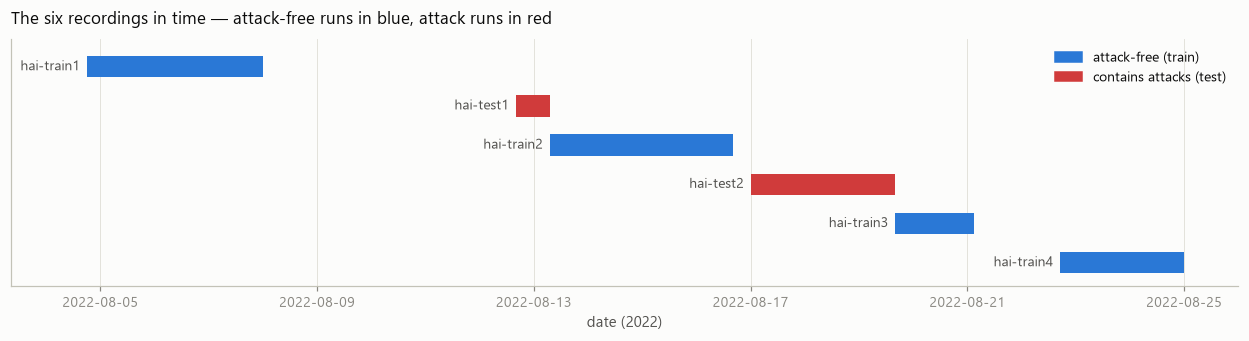

In [15]:
fig, ax = plt.subplots(figsize=(11.5, 3.2))

for i, k in enumerate(order):
    a, b, _ = spans[k]
    is_test = k in TEST
    ax.barh(i, (b - a).total_seconds() / 86400, left=mpl.dates.date2num(a), height=0.55,
            color=ATTACK if is_test else NORMAL, linewidth=0)
    ax.text(mpl.dates.date2num(a) - 0.12, i, k, ha="right", va="center",
            fontsize=9, color=INK2)
ax.set_yticks([])
ax.invert_yaxis()
ax.xaxis_date()
ax.grid(axis="y", visible=False)
ax.set(title="The six recordings in time — attack-free runs in blue, attack runs in red",
       xlabel="date (2022)")
ax.set_xlim(mpl.dates.date2num(spans["hai-train1"][0]) - 1.4,
            mpl.dates.date2num(spans["hai-train4"][1]) + 1.0)
ax.set_ylim(len(order) - 0.4, -0.7)
handles = [mpl.patches.Patch(color=NORMAL, label="attack-free (train)"),
           mpl.patches.Patch(color=ATTACK, label="contains attacks (test)")]
ax.legend(handles=handles, loc="upper right")
fig.tight_layout()
plt.show()

**The runs are disjoint and interleaved in a specific, useful way**: an attack-free
run, then an attack run, then attack-free, then attack, then two attack-free.

In [21]:
cols = {name: list(pd.read_csv(BASE / f"{name}.csv", nrows=0).columns)
        for name in TRAIN + TEST}
ref_name, ref = TRAIN[0], cols[TRAIN[0]]

print(f"reference: {ref_name}, {len(ref)} columns")
print(f"{'file':<14}{'cols':>6}{'same names':>13}{'same order':>13}{'difference':>13}")
for name, c in cols.items():
    absent = [x for x in ref if x not in c]
    extra = [x for x in c if x not in ref]
    diff = "-" if not (absent or extra) else f"-{len(absent)} +{len(extra)}"
    print(f"{name:<14}{len(c):>6}{str(set(c) == set(ref)):>13}"
          f"{str(c == ref):>13}{diff:>13}")
    for x in absent:
        print(f"      absent from {name}: {x}")
    for x in extra:
        print(f"      only in {name}: {x}")

agree = all(c == ref for c in cols.values())
print()
print(f"-> the {len(cols)} data files {'all carry' if agree else 'do NOT carry'} the "
      f"same {len(ref)} columns, in the same order")


padded = {n: [c for c in v if c != c.strip()] for n, v in cols.items()}
repeated = {n: sorted({c for c in v if v.count(c) > 1}) for n, v in cols.items()}
padded = {n: v for n, v in padded.items() if v}
repeated = {n: v for n, v in repeated.items() if v}
print(f"   names with surrounding whitespace : {padded or 'none'}")
print(f"   names repeated within one file    : {repeated or 'none'}")


reference: hai-train1, 87 columns
file            cols   same names   same order   difference
hai-train1        87         True         True            -
hai-train2        87         True         True            -
hai-train3        87         True         True            -
hai-train4        87         True         True            -
hai-test1         87         True         True            -
hai-test2         87         True         True            -

-> the 6 data files all carry the same 87 columns, in the same order
   names with surrounding whitespace : none
   names repeated within one file    : none


---
## 3. Which variables are present

86 tags, named by process and function. The naming is not a fixed type prefix, but
the convention is readable and encodes one distinction that turns out to matter:

```
      P1_FCV01D
      │  │   ││
      │  │   │└─ D = demand (the command the controller sends)
      │  │   │   Z = position (what the instrument reports back)
      │  │   └── instrument number
      │  └────── function: FCV flow-control valve, LCV level-control valve,
      │          PCV pressure-control valve, LIT level, PIT pressure, TIT
      │          temperature, FT flow, PP pump, SOL solenoid, VIBTR vibration
      └───────── process (P1-P4), or x1xxx for the HIL simulator points
```

The **D/Z distinction is the interesting one**. A command and its position feedback
describe the same valve from two sides, and the documented attack model manipulates
the command while spoofing the measurement — so the pair is exactly what a stealthy
attack has to break.

In [24]:

frames = []
for name in TRAIN + TEST:
    f = pd.read_csv(BASE / f"{name}.csv", low_memory=False)
    ts = pd.DatetimeIndex(pd.to_datetime(f.pop("timestamp")), name="timestamp")
    f = f.apply(pd.to_numeric, errors="coerce").astype("float32").set_axis(ts)
    f["source"] = name
    frames.append(f)

full = pd.concat(frames).sort_index(kind="stable")
full["source"] = pd.Categorical(full["source"], categories=TRAIN + TEST)
del frames

tags = [c for c in full.columns if c != "source"]
V = full[tags]


def process_of(name: str) -> str:
    m = re.match(r"^(P\d)_", name)
    return m.group(1) if m else "HIL"


meta = pd.DataFrame({"tag": tags, "process": [process_of(c) for c in tags]})
meta["levels"] = [int(V[c].nunique()) for c in tags]
meta["kind"] = np.where(meta["levels"] <= 5, "categorical", "numeric")

print(f"{len(TRAIN + TEST)} files -> {len(full):,} rows x {len(tags)} tags   "
      f"missing values: {int(V.isna().to_numpy().sum())}")
print(f"memory {full.memory_usage(deep=True).sum() / 1e6:,.0f} MB   "
      f"span {full.index[0]} -> {full.index[-1]}")
print()
print(full["source"].value_counts().reindex(TRAIN + TEST).to_frame("rows").to_string())
print()
print(meta.groupby(["process", "kind"]).size().unstack(fill_value=0).to_string())
print()
print("levels: max among categorical =",
      int(meta.loc[meta.kind == "categorical", "levels"].max()),
      "| min among numeric =",
      int(meta.loc[meta.kind == "numeric", "levels"].min()))

6 files -> 1,180,800 rows x 86 tags   missing values: 0
memory 417 MB   span 2022-08-04 18:00:01 -> 2022-08-25 00:00:00

              rows
source            
hai-train1  280800
hai-train2  291600
hai-train3  126000
hai-train4  198000
hai-test1    54000
hai-test2   230400

kind     categorical  numeric
process                         
HIL                0           7
P1                11          26
P2                13          11
P3                 2           5
P4                 0          11

levels: max among categorical = 2 | min among numeric = 17


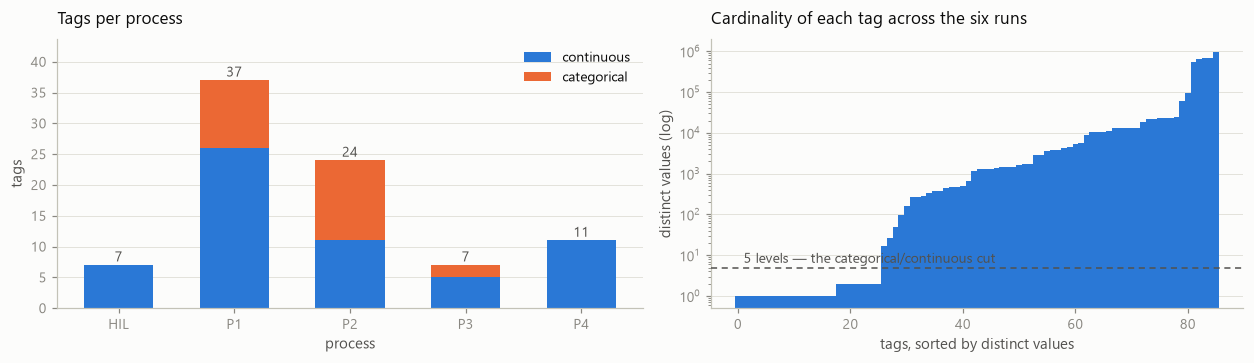

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.4), gridspec_kw={"width_ratios": [1.1, 1]})


piv = meta.groupby(["process", "kind"]).size().unstack(fill_value=0)
piv = piv.reindex(columns=["numeric", "categorical"], fill_value=0)
x = np.arange(len(piv))
ax1.bar(x, piv["numeric"], color=C[0], width=0.6, label="numeric")
ax1.bar(x, piv["categorical"], bottom=piv["numeric"], color=C[1], width=0.6, label="categorical")
for i, (c_, d_) in enumerate(zip(piv["numeric"], piv["categorical"])):
    ax1.text(i, c_ + d_ + 0.6, str(c_ + d_), ha="center", color=INK2, fontsize=9)
ax1.set_xticks(x, piv.index)
ax1.set(xlabel="process", ylabel="tags", title="Tags per process",
        ylim=(0, (piv.sum(axis=1).max()) * 1.18))
ax1.grid(axis="x", visible=False)
ax1.legend(loc="upper right")


lv = np.sort(meta["levels"].to_numpy())
ax2.bar(range(len(lv)), lv, color=C[0], width=1.0)
ax2.set_yscale("log")
ax2.axhline(5, color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)
ax2.text(1, 6.5, "5 levels — the categorical/numeric cut", color=INK2, fontsize=9)
ax2.set(xlabel="tags, sorted by distinct values", ylabel="distinct values (log)",
        title="Cardinality of each tag across the six runs")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

---
## 4. Data quality

Three checks on the concatenated table rather than on one file, because two of the
three can only be answered there: a row can duplicate a row in a different file, and
a tag that looks constant in one run may move in another.

None of them is asked out of ritual. Each has a known failure in this project's
other datasets -- SWaT turned out to be a third exact copies of itself, timestamps
included, and ESA has channels that report nothing for the first fifty-eight days.
What follows is whether HAI does the same.


In [26]:
# ---- columns that never change ------------------------------------------------
# A constant column is not harmless. It enters every distance computation as a zero,
# every correlation as an undefined value, and any standardisation as a division by
# zero -- and here it is a fifth of the width.
nunique = V.nunique()
const = sorted(nunique[nunique <= 1].index)
print(f"CONSTANT COLUMNS, measured over all {len(full):,} rows")
print(f"   {len(const)} of {len(tags)} tags take one single value "
      f"({len(const) / len(tags):.0%}):")
for i in range(0, len(const), 5):
    print("      " + ", ".join(const[i:i + 5]))

# Constancy is a property of the window it is measured over, so the same question
# goes to each file. Two cases only this view separates: a tag constant within every
# run but at a different level in each, which is a sensor rescaled between campaigns
# rather than a dead one, and a tag constant in some runs and not others, which is a
# signal that only fires under a condition those runs do not contain.
per_file = V.groupby(full["source"], observed=True).nunique()
flat_each = [t for t in tags if (per_file[t] <= 1).all()]
drift = [t for t in flat_each if t not in const]
partial = [t for t in tags if (per_file[t] <= 1).any() and t not in flat_each]
partial.sort(key=lambda t: -int((per_file[t] <= 1).sum()))

print()
print(f"   constant inside every file taken on its own     : {len(flat_each)}")
print(f"   ...of those, constant at a DIFFERENT value per file: {len(drift)} "
      f"{drift if drift else ''}")
print(f"   constant in some files but not in others        : {len(partial)}")
for t in partial:
    flat_in = per_file.index[per_file[t] <= 1].tolist()
    print(f"      {t:<13} flat in {len(flat_in)}/6: {', '.join(flat_in)}")

# ---- rows that repeat ----------------------------------------------------------
# Two questions that are easy to conflate and are not the same defect. A row
# identical to another in every reading may be a genuine repeat of a steady state. A
# row sharing a timestamp with another cannot be: one instant has one reading, so a
# repeated timestamp means two sources of truth for the same second.
print()
print("DUPLICATE ROWS")
dup_vals = V.duplicated(keep="first")
dup_ts = full.index.duplicated(keep="first")
both = dup_vals.to_numpy() & dup_ts
print(f"   identical across all {len(tags)} tag values : {int(dup_vals.sum()):,} "
      f"({dup_vals.mean():.3%})")
print(f"   sharing an exact timestamp               : {int(dup_ts.sum()):,} "
      f"({dup_ts.mean():.3%})")
print(f"   both at once                             : {int(both.sum()):,}")

if dup_vals.any():
    by_src = dup_vals.groupby(full["source"], observed=True).sum()
    print("   value-duplicates by file:")
    for k, v in by_src.items():
        n = int((full["source"] == k).sum())
        print(f"      {k:<12} {int(v):>8,} of {n:>9,} ({v / n:.3%})")
    print(f"   {len(full):,} rows collapse to {len(full) - int(dup_vals.sum()):,} "
          f"distinct readings")
else:
    print("   -> no row repeats another across all 86 readings at once")

if dup_ts.any():
    print("   timestamp-duplicates by file:")
    print(pd.Series(full.index[dup_ts]).groupby(
        full["source"].to_numpy()[dup_ts]).size().to_string())
else:
    print("   -> no instant appears twice: the six runs are disjoint in fact and "
          "not only in their declared spans, and no file repeats a second internally")

CONSTANT COLUMNS, measured over all 1,180,800 rows
   18 of 86 tags take one single value (21%):
      P1_PIT01_HH, P1_PP01AD, P1_PP01AR, P1_PP01BD, P1_PP01BR
      P1_PP02D, P1_PP02R, P1_SOL01D, P1_SOL03D, P1_STSP
      P2_RTR, P2_TripEx, P2_VTR01, P2_VTR02, P2_VTR03
      P2_VTR04, P3_LH01, P3_LL01

   constant inside every file taken on its own     : 18
   ...of those, constant at a DIFFERENT value per file: 0 
   constant in some files but not in others        : 10
      P2_Emerg      flat in 5/6: hai-train1, hai-train2, hai-train3, hai-train4, hai-test1
      P2_OnOff      flat in 5/6: hai-train1, hai-train2, hai-train3, hai-train4, hai-test1
      P1_PP04SP     flat in 2/6: hai-train3, hai-test1
      P1_PCV02D     flat in 1/6: hai-train3
      P2_ATSW_Lamp  flat in 1/6: hai-test1
      P2_AutoGO     flat in 1/6: hai-test1
      P2_MASW       flat in 1/6: hai-test1
      P2_MASW_Lamp  flat in 1/6: hai-test1
      P2_ManualGO   flat in 1/6: hai-test1
      P2_ManualSD   flat in 1/

**HAI is clean where SWaT was not.** Zero rows identical across all 86 readings,
zero rows sharing a timestamp. The six runs are disjoint in fact and not merely in
their declared spans, and no file repeats a second internally. Nothing has to be
de-duplicated and nothing has to be re-ordered.

**A fifth of the width carries nothing.** 18 of the 86 tags take a single value over
all 1.18 million rows -- pump run/demand flags in P1, the turbine's vibration-trip
set `P2_VTR01`-`P2_VTR04`, the level switches `P3_LH01` and `P3_LL01`. They are
constant *at the same value* in every file, so this is a testbed configuration that
never varied rather than a scale that shifted between campaigns. They can be dropped
without losing anything, and should be: a constant column is a zero in every distance
and an undefined value in every correlation.

**Ten more are constant in some runs and not others, and the two groups mean
different things.**

Six P2 tags are flat only in `hai-test1`, and `P1_PP04SP` is flat in `hai-test1` and
`hai-train3`. Those are the two shortest runs -- 15 and 35 hours. A signal that
switches a few times a day looks constant inside a 15-hour window, so this says more
about the length of the run than about the tag.

`P2_Emerg` and `P2_OnOff` are the exception worth stopping on: **flat in five of six
files, moving only in `hai-test2`**. The turbine's emergency flag and its on/off
state are inert through every training run, through `hai-test1`, and change only in
the long attack run. If a model is fitted on `train1`-`train4` these two tags are
constant in everything it ever sees, so any movement at test time is a perfect
signal that costs nothing to detect and says nothing about the process. They should
be excluded deliberately, or kept deliberately -- but the choice has to be made,
because leaving them in makes a detector look good for the wrong reason.


---
## 5. The attacks

The official documentation lists **52 attacks** for 23.05 — 42 single primitives and
10 combinations that run two primitives at once — each with a date, a start time and
a duration.

In [22]:
def load_labels(name: str) -> np.ndarray:
    return pd.read_csv(BASE / f"{name}.csv")["label"].to_numpy()

def segments(y: np.ndarray):
    ch = np.diff(np.r_[0, (y != 0).astype(int), 0])
    return np.flatnonzero(ch == 1), np.flatnonzero(ch == -1)

labels, segs = {}, {}
for data, lab in zip(TEST, LABEL):
    y = load_labels(lab)
    s, e = segments(y)
    labels[data], segs[data] = y, e - s
    print(f"{data}: {len(y):,} rows, {int((y != 0).sum()):,} attack seconds "
          f"({(y != 0).mean():.2%}), {len(s)} segments")
print()
y_all = np.concatenate([labels[d] for d in TEST])
d_all = np.concatenate([segs[d] for d in TEST])
print(f"pooled : {len(y_all):,} rows, {int((y_all != 0).sum()):,} attack seconds "
      f"({(y_all != 0).mean():.2%}), {len(d_all)} segments")
print()
print("The documentation lists 14 attacks on 12-13 August and 38 on 17-19 August,")
print("for 52 in total. The labels give exactly those counts, one segment per attack.")

hai-test1: 54,000 rows, 2,981 attack seconds (5.52%), 14 segments
hai-test2: 230,400 rows, 8,403 attack seconds (3.65%), 38 segments

pooled : 284,400 rows, 11,384 attack seconds (4.00%), 52 segments

The documentation lists 14 attacks on 12-13 August and 38 on 17-19 August,
for 52 in total. The labels give exactly those counts, one segment per attack.


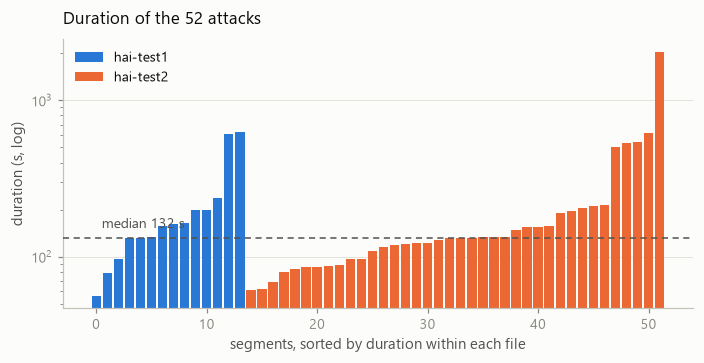

In [23]:
fig, ax1 = plt.subplots(figsize=(6.5, 3.4))


for name, col, off in (
    ("hai-test1", C[0], 0),
    ("hai-test2", C[1], len(segs["hai-test1"])),
):
  d = np.sort(segs[name])
  ax1.bar(np.arange(len(d)) + off, d, color=col, width=0.85, label=name)

ax1.set_yscale("log")
ax1.axhline(
    np.median(d_all), color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3
)
ax1.text(
    0.5,
    np.median(d_all) * 1.15,
    f"median {np.median(d_all):.0f} s",
    color=INK2,
    fontsize=9,
)
ax1.set(
    xlabel="segments, sorted by duration within each file",
    ylabel="duration (s, log)",
    title=f"Duration of the {len(d_all)} attacks",
)
ax1.grid(axis="x", visible=False)
ax1.legend(loc="upper left")

fig.tight_layout()
plt.show()

**The durations are short**: median 132 seconds.

            attacks  attack seconds  mean duration (s) share of attack seconds
timestamp                                                                     
2022-08-12        8            1821              228.0                   16.0%
2022-08-13        6            1160              193.0                   10.2%
2022-08-17       19            3696              195.0                   32.5%
2022-08-18        9            1084              120.0                    9.5%
2022-08-19       10            3623              362.0                   31.8%

the campaign runs over 5 calendar days, 10.4 attacks a day on average; busiest 19, quietest 6
the busiest day holds 37% of the attacks and 32% of the attack seconds


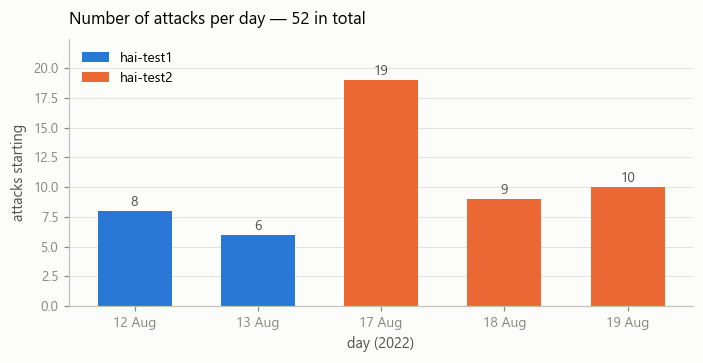

In [27]:
# When the attacks happen, by calendar day. The durations above say how long each
# one lasts; this says how they are spread, which is the other half of what decides
# whether a per-row metric is really measuring one busy afternoon.
starts, seconds = {}, {}
for data, lab in zip(TEST, LABEL):
    lf = pd.read_csv(BASE / f"{lab}.csv")
    y = lf["label"].to_numpy()
    day = pd.to_datetime(lf["timestamp"]).dt.normalize()
    s, _ = segments(y)
    starts[data] = day.iloc[s]
    # Attack seconds per day as well as attack count: a day can be busy in events
    # and light in mass, and only the second of the two moves a per-row metric.
    seconds[data] = day[y != 0].value_counts()

per_day = pd.DataFrame({k: v.value_counts() for k, v in starts.items()}).fillna(0)
per_day = per_day.sort_index().astype(int)
per_sec = pd.DataFrame(seconds).fillna(0).sort_index().astype(int)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
x = np.arange(len(per_day))
bottom = np.zeros(len(per_day))
for name, col in zip(TEST, (C[0], C[1])):
    ax.bar(x, per_day[name], bottom=bottom, color=col, width=0.6, label=name)
    bottom += per_day[name].to_numpy()
for i, t in enumerate(bottom):
    ax.text(i, t + 0.4, str(int(t)), ha="center", color=INK2, fontsize=9)
ax.set_xticks(x, [f"{d:%d %b}" for d in per_day.index])
ax.set(xlabel="day (2022)", ylabel="attacks starting",
       title=f"Number of attacks per day — {int(per_day.to_numpy().sum())} in total",
       ylim=(0, bottom.max() * 1.18))
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

table = pd.DataFrame({
    "attacks": per_day.sum(axis=1),
    "attack seconds": per_sec.sum(axis=1),
})
table["mean duration (s)"] = (table["attack seconds"] / table["attacks"]).round(0)
table["share of attack seconds"] = (
    table["attack seconds"] / table["attack seconds"].sum()).map("{:.1%}".format)
print(table.to_string())
print()
print(f"the campaign runs over {len(per_day)} calendar days, "
      f"{per_day.to_numpy().sum() / len(per_day):.1f} attacks a day on average; "
      f"busiest {per_day.sum(axis=1).max()}, quietest {per_day.sum(axis=1).min()}")
print(f"the busiest day holds {table['attacks'].max() / table['attacks'].sum():.0%} of "
      f"the attacks and {table.loc[table['attacks'].idxmax(), 'attack seconds'] / table['attack seconds'].sum():.0%} "
      f"of the attack seconds")

**The 52 attacks fall on five calendar days, and they are not spread evenly over
them.** 17 August carries 19 of them, more than three times the quietest day, and
the two days of `hai-test1` carry 14 between them. The shape follows the campaign
schedule rather than anything about the plant: each test file is a separate
campaign, and `hai-test2` ran 38 attacks over three days against `hai-test1`'s 14
over two.

**Count and mass do not track each other**, which is the reason the table prints
both. 17 August has the most attacks and 32.5% of the attack seconds; 19 August has
roughly half as many attacks and almost exactly the same share of seconds, because
its mean duration is 362 seconds against 195. A day can be busy in events and light
in mass, and only the mass moves a per-row metric.

Still, no day dominates: the heaviest holds a third of the attack seconds. That is
the opposite of SWaT, where one ten-hour segment carried 66% of the attack instants
on its own, and it is what makes a pooled per-row metric defensible here.

---
## 6. Descriptive statistics

Everything in this section is computed on the **four training files joined into one
frame**, 896,400 rows. The test runs are deliberately left out: these numbers are
meant to describe what normal operation looks like, and a baseline that silently
includes 11,384 seconds of attack is not that baseline.

The 86 tags are described two different ways because they are two different kinds of
thing. A mean and a standard deviation say something about a flow rate and nothing
at all about a two-state switch; the switch needs to be described by which state it
sits in and how often it leaves it. The same split governs the correlations:
Pearson for the numeric tags, a contingency test for the categorical ones.

### The numeric tags

In [28]:
# Training files only. Descriptive statistics here are meant to characterise normal
# operation, and the two test runs are where the attacks are -- mixing them in would
# describe a plant under attack 4% of the time and call it the baseline. The four
# training runs concatenate safely for the same reason as before: they are disjoint.
train = full.loc[full["source"].isin(TRAIN)].copy()
train["source"] = train["source"].cat.remove_unused_categories()
cont = meta.loc[meta["kind"] == "numeric", "tag"].tolist()
cat = meta.loc[meta["kind"] == "categorical", "tag"].tolist()

print(f"{len(TRAIN)} training files -> {len(train):,} rows "
      f"({len(train) / len(full):.0%} of everything)")
print(f"   {len(cont)} numeric, {len(cat)} categorical")
# The split was drawn in section 3 on all six files. Re-deriving it here on the
# training half alone has to give the same answer, or the two sections disagree.
lv = train.nunique()
assert set(lv.index[lv > 5]) == set(cont), "the categorical/numeric cut moves on train alone"
print(f"   the cut at five levels is unchanged when measured on training alone")
print(f"   constant within training: {int((lv[cont] <= 1).sum())} numeric, "
      f"{int((lv[cat] <= 1).sum())} categorical")

desc = train[cont].describe().T
desc[["count", "mean", "std", "min", "50%", "max"]].round(3)

4 training files -> 896,400 rows (76% of everything)
   60 numeric, 26 categorical
   the cut at five levels is unchanged when measured on training alone
   constant within training: 0 numeric, 20 categorical


,count,mean,std,min,50%,max
P1_FCV01D,896400.0,30.052,24.718,0.000,20.158,92.239
P1_FCV01Z,896400.0,29.889,24.990,0.314,20.013,92.195
P1_FCV02D,896400.0,47.103,40.904,15.000,15.000,100.000
P1_FCV02Z,896400.0,42.694,38.031,12.292,12.697,97.726
P1_FCV03D,896400.0,55.073,3.550,47.687,54.194,68.652
P1_FCV03Z,896400.0,55.777,3.635,48.334,54.819,69.711
P1_FT01,896400.0,62.730,7.821,0.801,62.408,198.784
P1_FT01Z,896400.0,326.602,40.504,4.171,324.940,892.227
P1_FT02,896400.0,981.203,1014.637,1.183,454.941,2506.676
P1_FT02Z,896400.0,1535.775,1267.913,6.157,1351.661,3190.000


### The categorical tags

Not a mean but a state. Transitions are counted **inside each run and then summed**:
the four files are concatenated, so a change across a file boundary is an artefact
of the join rather than a switch the actuator performed.

In [29]:
# The categorical tags do not have a mean worth printing. What describes a two-state
# signal is which state it sits in, how lopsided that is, and how often it moves.
rows = []
for c in cat:
    s = train[c]
    vc = s.value_counts(normalize=True)
    # Transitions counted inside each run and then summed. The four files are
    # concatenated, so a change across a file boundary is an artefact of the join
    # and not a switch the actuator performed.
    moves = int(sum((train.loc[train["source"] == f, c].diff() != 0).sum() - 1
                    for f in TRAIN))
    rows.append({"tag": c, "levels": int(s.nunique()),
                 "dominant state": float(vc.index[0]),
                 "dominant share": round(float(vc.iloc[0]), 4),
                 "transitions": moves})

actuators = pd.DataFrame(rows).sort_values(
    ["transitions", "dominant share"], ascending=[False, False]).reset_index(drop=True)
print(actuators.to_string(index=False))
print()
frozen = actuators.loc[actuators["transitions"] == 0, "tag"].tolist()
print(f"{len(frozen)} of {len(cat)} categorical tags never change state in training")
print(f"   the {len(cat) - len(frozen)} that do are all binary, and the busiest is "
      f"{actuators.iloc[0]['tag']} with {actuators.iloc[0]['transitions']:,} switches "
      f"in {len(train):,} seconds")

         tag  levels  dominant state  dominant share  transitions
    P1_PP04D       2             1.0          0.6246          481
P2_ATSW_Lamp       2             1.0          0.8883           24
   P2_AutoGO       2             1.0          0.8883           24
     P2_MASW       2             0.0          0.8883           24
P2_MASW_Lamp       2             0.0          0.8883           24
 P2_ManualGO       2             0.0          0.8883           24
 P1_PIT01_HH       1        524320.0          1.0000            0
   P1_PP01AD       1             0.0          1.0000            0
   P1_PP01AR       1             0.0          1.0000            0
   P1_PP01BD       1             1.0          1.0000            0
   P1_PP01BR       1             1.0          1.0000            0
    P1_PP02D       1             1.0          1.0000            0
    P1_PP02R       1             1.0          1.0000            0
   P1_SOL01D       1        524320.0          1.0000            0
   P1_SOL0

### Pearson, on the numeric tags

numeric tags: 60   constant in training and therefore dropped: 0
Pearson computed over 60 columns (1,770 pairs)

most strongly correlated pairs:
   P4_ST_TT01             ~ P1_TIT01               r = +0.9997   cross-process
   x1003_10_SETPOINT_OUT  ~ P1_FT02Z               r = +0.9997   cross-process
   P4_ST_GOV              ~ P4_ST_PO               r = +0.9993   same process
   P3_LCV01D              ~ P4_HT_PO               r = +0.9990   cross-process
   P1_FCV01Z              ~ P1_FCV01D              r = +0.9984   same process
   P1_FT03Z               ~ P1_FT03                r = +0.9968   same process
   P1_FT01                ~ P1_FT01Z               r = +0.9948   same process
   P1_FT03Z               ~ x1002_08_SETPOINT_OUT  r = +0.9912   cross-process
   P1_FCV03D              ~ P1_FCV03Z              r = +0.9910   same process
   x1002_08_SETPOINT_OUT  ~ P1_FT03                r = +0.9884   cross-process

1,770 distinct pairs   median |r| = 0.035   |r| > 0.8: 2.5%   |r| > 0

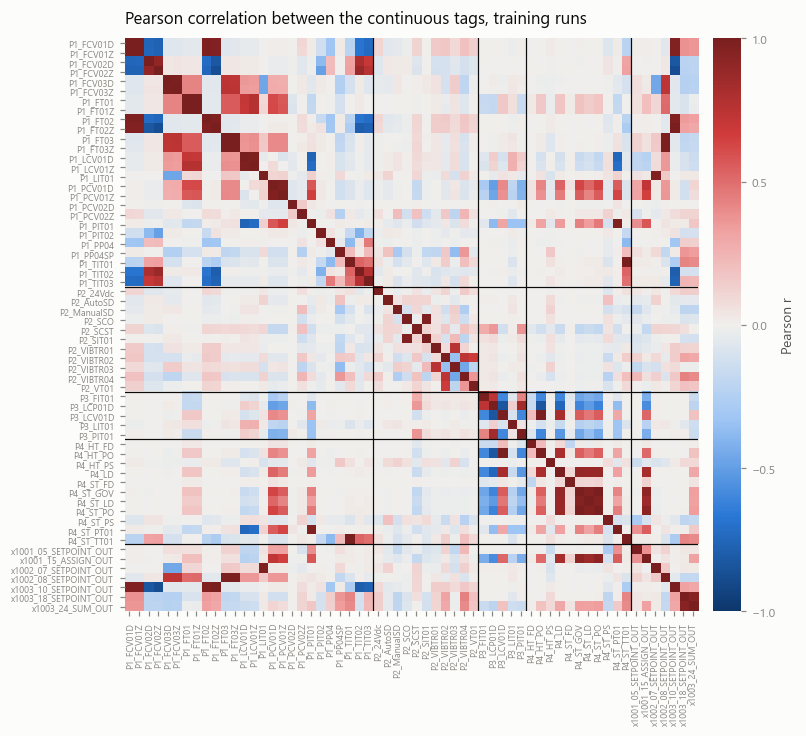

In [30]:
# Pearson on the numeric tags, over the training runs only.
numeric = [c for c in cont if train[c].std() > 1e-9]
dropped = sorted(set(cont) - set(numeric))
print(f"numeric tags: {len(cont)}   constant in training and therefore dropped: "
      f"{len(dropped)}")
if dropped:
    print("   " + ", ".join(dropped))
print(f"Pearson computed over {len(numeric)} columns "
      f"({len(numeric) * (len(numeric) - 1) // 2:,} pairs)")

corr = train[numeric].corr()          # method="pearson" is the default

fig, ax = plt.subplots(figsize=(8.0, 6.8))
div = mpl.colors.LinearSegmentedColormap.from_list(
    "div", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f0a0a0", "#d03b3b", "#7a1f1f"])
im = ax.imshow(corr.values, cmap=div, vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(range(len(numeric)), numeric, rotation=90, fontsize=6)
ax.set_yticks(range(len(numeric)), numeric, fontsize=6)
ax.set_title("Pearson correlation between the numeric tags, training runs")
ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)
procs = [process_of(c) for c in numeric]
for e in [i for i in range(1, len(procs)) if procs[i] != procs[i - 1]]:
    ax.axhline(e - 0.5, color=INK, linewidth=0.8)
    ax.axvline(e - 0.5, color=INK, linewidth=0.8)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cb.set_label("Pearson r", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

off = corr.where(~np.eye(len(corr), dtype=bool)).stack().sort_values(key=abs, ascending=False)
seen, top = set(), []
for (i, j), v in off.items():
    if (j, i) in seen:
        continue
    seen.add((i, j))
    top.append((i, j, float(v)))
    if len(top) == 10:
        break
print("\nmost strongly correlated pairs:")
for i, j, v in top:
    where = "same process" if process_of(i) == process_of(j) else "cross-process"
    print(f"   {i:<22} ~ {j:<22} r = {v:+.4f}   {where}")

vals = np.abs(corr.values[np.triu_indices(len(corr), 1)])
print()
print(f"{len(vals):,} distinct pairs   median |r| = {np.median(vals):.3f}   "
      f"|r| > 0.8: {(vals > 0.8).mean():.1%}   |r| > 0.5: {(vals > 0.5).mean():.1%}")

### Cramer's V, on the categorical tags

Pearson on a two-state signal measures nothing useful, so the categorical tags are
compared on their contingency table instead. **Cramer's V** is the measure reported:
for a 2x2 table it is `sqrt(chi2 / n)`, so it carries the same ordering as the
chi-square statistic on a scale that reads 0 to 1 and can go on a shared colour
axis. The chi-square is the engine and is not reported on its own.

categorical tags: 26   constant in training and therefore excluded: 20
Cramer's V computed over 6 columns (15 pairs)

pair                              Cramer V
P2_ATSW_Lamp ~ P2_ManualGO           1.000
P2_MASW ~ P2_MASW_Lamp               1.000
P2_AutoGO ~ P2_MASW                  1.000
P2_AutoGO ~ P2_MASW_Lamp             1.000
P2_ATSW_Lamp ~ P2_AutoGO             1.000
P2_AutoGO ~ P2_ManualGO              1.000
P2_ATSW_Lamp ~ P2_MASW               1.000
P2_ATSW_Lamp ~ P2_MASW_Lamp          1.000
P2_MASW ~ P2_ManualGO                1.000
P2_MASW_Lamp ~ P2_ManualGO           1.000
P1_PP04D ~ P2_MASW                   0.009
P1_PP04D ~ P2_MASW_Lamp              0.009
P1_PP04D ~ P2_AutoGO                 0.009
P1_PP04D ~ P2_ATSW_Lamp              0.009
P1_PP04D ~ P2_ManualGO               0.009

15 pairs   median V = 1.000   V > 0.8: 10   V > 0.5: 10   V < 0.05: 5


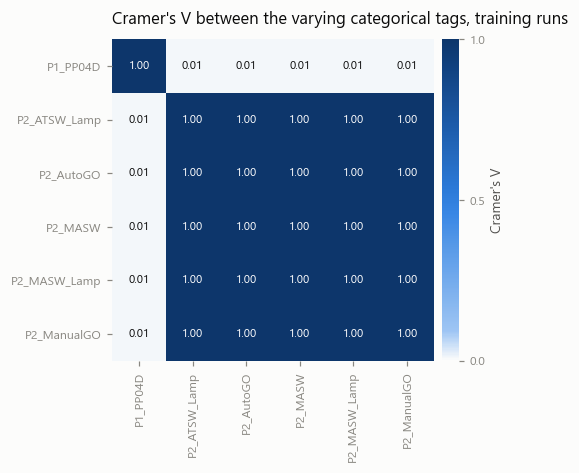

In [31]:
from scipy.stats import chi2_contingency

# Pearson on a two-state signal measures nothing useful, so the categorical tags get
# an association measure built on the contingency table instead: Cramer's V, which
# for a 2x2 table is sqrt(chi2 / n). The chi-square statistic is the engine and is
# not reported on its own -- every pair here is a 2x2 table over the same 896,400
# rows, so V carries exactly the same ordering on a scale that reads 0 to 1.
varying = [c for c in cat if train[c].nunique() > 1]
frozen_cat = [c for c in cat if c not in varying]
print(f"categorical tags: {len(cat)}   constant in training and therefore excluded: "
      f"{len(frozen_cat)}")
print(f"Cramer's V computed over {len(varying)} columns "
      f"({len(varying) * (len(varying) - 1) // 2} pairs)")

n = len(train)
cram = pd.DataFrame(np.eye(len(varying)), index=varying, columns=varying)
pairs = []
for i, a in enumerate(varying):
    for b in varying[i + 1:]:
        table = pd.crosstab(train[a], train[b])
        chi2 = chi2_contingency(table)[0]
        v = float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))
        cram.loc[a, b] = cram.loc[b, a] = v
        pairs.append((a, b, v))

fig, ax = plt.subplots(figsize=(5.2, 4.4))
seq = mpl.colors.LinearSegmentedColormap.from_list("seq", ["#fcfcfb"] + SEQ[2:])
im = ax.imshow(cram.values, cmap=seq, vmin=0, vmax=1, aspect="equal")
ax.set_xticks(range(len(varying)), varying, rotation=90, fontsize=8)
ax.set_yticks(range(len(varying)), varying, fontsize=8)
for i in range(len(varying)):
    for j in range(len(varying)):
        v = cram.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="#ffffff" if v > 0.6 else INK)
ax.set_title("Cramer's V between the varying categorical tags, training runs")
ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, ticks=[0, 0.5, 1])
cb.set_label("Cramer's V", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

print(f"\n{'pair':<32}{'Cramer V':>10}")
for a, b, v in sorted(pairs, key=lambda r: -r[2]):
    print(f"{a + ' ~ ' + b:<32}{v:>10.3f}")
vv = np.array([r[2] for r in pairs])
print()
print(f"{len(pairs)} pairs   median V = {np.median(vv):.3f}   "
      f"V > 0.8: {(vv > 0.8).sum()}   V > 0.5: {(vv > 0.5).sum()}   "
      f"V < 0.05: {(vv < 0.05).sum()}")

**Twenty of the 26 categorical tags never move in training.** Only six change state
at all, every one of them binary, and `P1_PP04D` alone accounts for 481 of the
switches against 24 for each of the others. Note also what the cardinality rule did
here: `P1_PIT01_HH` sits at a constant 524,320 and `P2_VTR01`-`P2_VTR04` at a
constant 50, and they are classed as categorical purely because one distinct value
is fewer than five. They are setpoints that were never changed, not states.

**Five of the six varying tags are the same switch reported five times.**
`P2_ATSW_Lamp`, `P2_AutoGO`, `P2_MASW`, `P2_MASW_Lamp` and `P2_ManualGO` have
Cramer's V = **1.000** on all ten pairs between them, identical dominant shares of
0.8883 and identical transition counts of 24. Two of them are inverted relative to
the other three -- the dominant state is 1 for some and 0 for others -- which is
exactly what auto/manual mode plus its indicator lamps would look like. V measures
association and not direction, so an inverted copy still reads 1.000, which is the
right answer here: knowing one of the five tells you all five.

For a distance-based method that is one bit of information counted five times, and
it will weigh five times what it should. `P1_PP04D` is the only categorical tag that
carries anything of its own: **V = 0.009** against every one of the five, which is
independence.

**The numeric side is sparse, and the pairs that are not sparse are mostly
trivial.** Over 1,770 pairs the median |r| is **0.035** and only 2.5% exceed 0.8.
Four of the ten strongest are a command against its own position feedback
(`P1_FCV01D ~ P1_FCV01Z`, `P1_FT03 ~ P1_FT03Z`, and so on) -- the D/Z pairing from
section 3, correlated because they describe one valve from two sides. The genuinely
interesting ones are the cross-process pairs above r = 0.999:
`P1_TIT01 ~ P4_ST_TT01` and `P3_LCV01D ~ P4_HT_PO` couple a physical process to the
HIL simulator, which is the coupling the testbed was built to produce.

---
## 7. Summary

**The dataset.** A boiler, a turbine and a water-treatment loop, coupled through a
hardware-in-the-loop power-generation simulator, 86 tags at 1 Hz and 52 attacks.

**What has to be handled.**

| issue | detail |
|---|---|
| labels are separate files | one label file per test file, aligned row for row |
| `train3`, `train4` follow every test | 324,000 attack-free with no tests afterwards |
| 18 of 86 tags are constant everywhere | plus 10 more constant in some runs; `P2_Emerg` and `P2_OnOff` move only in `hai-test2` |


**Coupling is sparse.** Over the 1,770 pairs of numeric tags the median |r|
is **0.035** and only **2.5%** exceed 0.8. Among the categorical tags the
opposite: five of the six that move are one switch reported five times,
Cramer's V = 1.000.

**What makes it tractable.**

- Files are **disjoint, ordered and gapless**.
- The labels are **complete and verifiable**: 52 segments against 52 documented
  attacks, with durations matching the published table to the second.
- The **attacks are spread evenly** through each run, so no single stretch dominates
  the totals.
